# Coveda Technology
### Role : Data Analytics
### Name : DOEUN Bunheng
### ID   :- CV/A1/86646
### Date : 16/08/2026

# Task 1: Regression Analysis

Description: Perform a simple linear regression
analysis to predict one variable based on another
Split the dataset into training and testing sets.
Fit a linear regression model using scikit-learn.
Interpret the coefficients and evaluate the model using
metrics such as R-squared and mean squared error.
### Objectives:
Tools: Python, scikit-learn, pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df1 = pd.read_csv("cleaned_iris_dataset.csv")
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Data Preparation for Regression

For this regression task, let's consider `petal_width` as our target variable (y) and the other numerical features (`sepal_length`, `sepal_width`, `petal_length`) as our independent variables (X).

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.1 KB


In [5]:
df1.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
X = df1[['sepal_length', 'sepal_width', 'petal_length']]
y = df1['petal_width']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 117 samples
Test set size: 30 samples


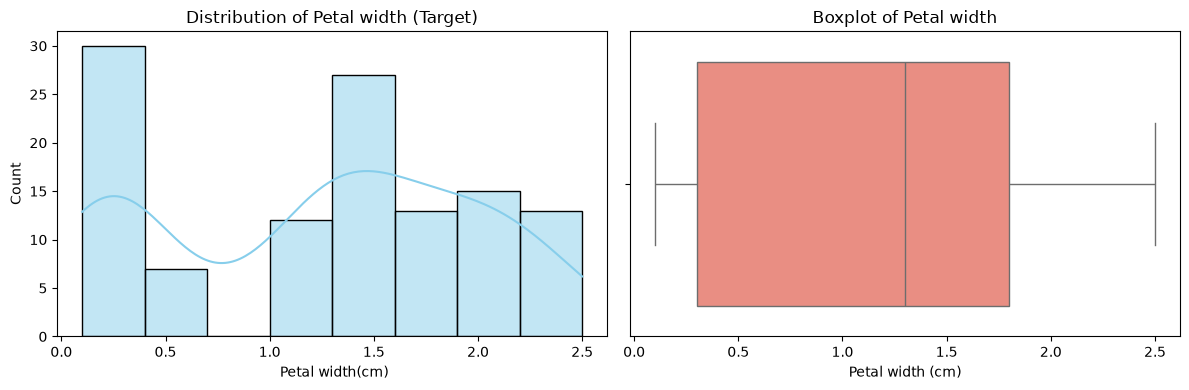

Petal width Descriptive Statistics (Train):
 count    117.000000
mean       1.224786
std        0.752915
min        0.100000
25%        0.300000
50%        1.300000
75%        1.800000
max        2.500000
Name: petal_width, dtype: float64


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_train, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Petal width (Target)")
axes[0].set_xlabel(" Petal width(cm)")

sns.boxplot(x=y_train, ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Petal width")
axes[1].set_xlabel("Petal width (cm)")

plt.tight_layout()
plt.show()

print("Petal width Descriptive Statistics (Train):\n", y_train.describe())

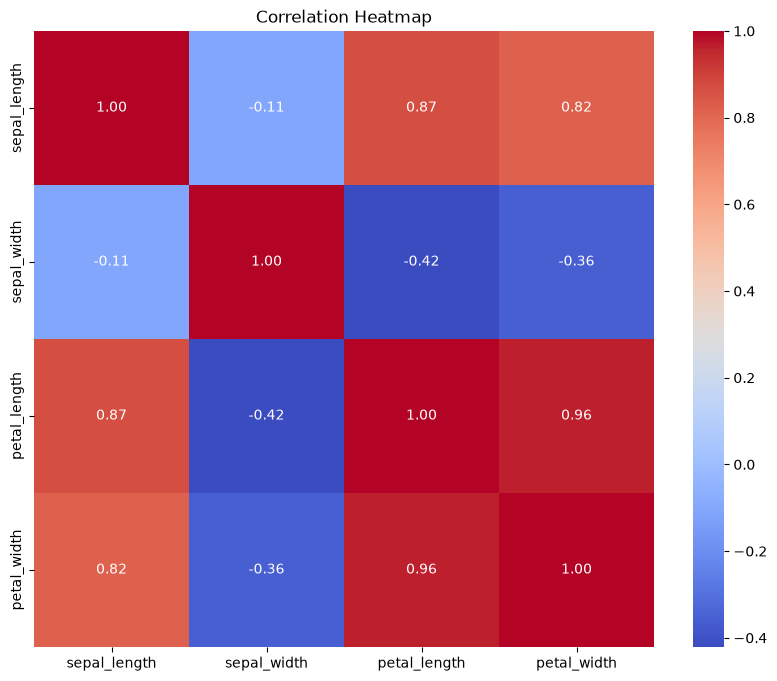

In [8]:
# heatmap correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Combine training presictors and target to compute Pearson correlation.

In [9]:
train_df1 = X_train.copy()
train_df1['petal_width'] = y_train
correlations = train_df1.corr(numeric_only=True)
corr_table = pd.DataFrame({"Correlation with Petal width": correlations['petal_width']})

print("Ranked Correlation Table:")
display(corr_table.sort_values(by="Correlation with Petal width", ascending=False))

Ranked Correlation Table:


,Correlation with Petal width
petal_width,1.000000
petal_length,0.959498
sepal_length,0.818314
sepal_width,-0.354307


In [10]:
best_feature = correlations['petal_width'].drop('petal_width').abs().idxmax()
print(f"The best predictor for using in linear regression: {best_feature}\n")


The best predictor for using in linear regression: petal_length



### Linear Regression Model Training

Now, let's fit a linear regression model to the training data.

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained.")

Linear Regression Model Trained.


### Model Evaluation and Interpretation

Let's evaluate the model's performance on the test set and interpret the coefficients.

In [12]:
# check VIF
core_feature = ["sepal_length","sepal_width", "petal_length"]
X_core_const = sm.add_constant(X_train[core_feature])

vif_table = pd.DataFrame({
    "Feature": X_core_const.columns,
    "VIF": [variance_inflation_factor(X_core_const.values, i) for i in range(X_core_const.shape[1])]
}).sort_values(by="VIF", ascending=False)

print("VIF Summary (Core Predictors):")
display(vif_table)

VIF Summary (Core Predictors):


,Feature,VIF
0,const,135.790421
3,petal_length,7.940048
1,sepal_length,6.601833
2,sepal_width,1.860733


In [13]:
# drop sepal_length and sepal_width
drop_feature = ["sepal_length","sepal_width"]
drop_feature

['sepal_length', 'sepal_width']

In [14]:
X_train_dropped = X_train.drop(columns=drop_feature)
X_test_dropped = X_test.drop(columns=drop_feature)

model.fit(X_train_dropped, y_train)

y_pred = model.predict(X_test_dropped)


In [15]:
y_pred = model.predict(X_test_dropped)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X_train_dropped.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
display(coefficients)

print(f"Intercept: {model.intercept_:.4f}")

Mean Squared Error (MSE): 0.0360
R-squared (R2): 0.9399

Model Coefficients:


,Feature,Coefficient
0,petal_length,0.409088


Intercept: -0.3472


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained.")

Linear Regression Model Trained.


In [17]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
display(coefficients)

print(f"Intercept: {model.intercept_:.4f}")

Mean Squared Error (MSE): 0.0352
R-squared (R2): 0.9412

Model Coefficients:


,Feature,Coefficient
0,sepal_length,-0.238197
1,sepal_width,0.247108
2,petal_length,0.532391


Intercept: -0.1721


In [18]:

# --- Evaluation of Model with ALL Features ---
# The 'model' variable in the kernel is currently the one trained on all features.
# 'y_pred' (from the last full model run), 'mse', 'r2' are also for the full model.

y_pred_all_features = model.predict(X_test) # Predict using the full model (current state)
mse_all_features = mean_squared_error(y_test, y_pred_all_features)
r2_all_features = r2_score(y_test, y_pred_all_features)
mae_all_features = mean_absolute_error(y_test, y_pred_all_features)
rmse_all_features = np.sqrt(mse_all_features)

print("--- Evaluation of Model with ALL Features ---")
print(f"Mean Squared Error (MSE): {mse_all_features:.4f}")
print(f"R-squared (R2): {r2_all_features:.4f}")
print(f"Mean Absolute Error (MAE): {mae_all_features:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_all_features:.4f}\n")

# --- Evaluation of Model with ONLY the Best Feature ('petal_length') ---
print(f"--- Evaluation of Model with ONLY '{best_feature}' ---")

# Prepare data for the single best feature model
X_train_single = X_train[[best_feature]]
X_test_single = X_test[[best_feature]]

# Re-initialize and train a new model for the single feature
model_single_feature = LinearRegression()
model_single_feature.fit(X_train_single, y_train)

# Make predictions and calculate metrics for the single feature model
y_pred_single = model_single_feature.predict(X_test_single)
mse_single = mean_squared_error(y_test, y_pred_single)
r2_single = r2_score(y_test, y_pred_single)
mae_single = mean_absolute_error(y_test, y_pred_single)
rmse_single = np.sqrt(mse_single)

print(f"Mean Squared Error (MSE): {mse_single:.4f}")
print(f"R-squared (R2): {r2_single:.4f}")
print(f"Mean Absolute Error (MAE): {mae_single:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_single:.4f}\n")

print("Comparison Summary")
comparison_data = {
    'Metric': ['MSE', 'R2', 'MAE', 'RMSE'],
    'Model with ALL Features': [mse_all_features, r2_all_features, mae_all_features, rmse_all_features],
    f'Model with ONLY {best_feature}': [mse_single, r2_single, mae_single, rmse_single]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

--- Evaluation of Model with ALL Features ---
Mean Squared Error (MSE): 0.0352
R-squared (R2): 0.9412
Mean Absolute Error (MAE): 0.1515
Root Mean Squared Error (RMSE): 0.1877

--- Evaluation of Model with ONLY 'petal_length' ---
Mean Squared Error (MSE): 0.0360
R-squared (R2): 0.9399
Mean Absolute Error (MAE): 0.1392
Root Mean Squared Error (RMSE): 0.1896

Comparison Summary


,Metric,Model with ALL Features,Model with ONLY petal_length
0,MSE,0.0352,0.0360
1,R2,0.9412,0.9399
2,MAE,0.1515,0.1392
3,RMSE,0.1877,0.1896


###  Model Evaluation & Discussion

We evaluated and compared two linear regression models to determine the impact of removing collinear features:
1. **Full Model:** Built using all original features (`petal_length`, `sepal_length`, and `sepal_width`).
2. **Simplified Model:** Built using **only `petal_length`** as the core predictor.

---

####  Performance Comparison Summary

| Metric | Model with ALL Features | Model with ONLY `petal_length` | Delta ($\Delta$) |
| :--- | :---: | :---: | :---: |
| **R-squared ($R^2$)** | 0.9412 | 0.9399 | -0.0013 |
| **Mean Absolute Error (MAE)** | 0.1515 | 0.1392 | -0.0123 (Improved) |
| **Mean Squared Error (MSE)** | 0.0352 | 0.0360 | +0.0008 |
| **Root Mean Squared Error (RMSE)** | 0.1877 | 0.1896 | +0.0009 |

---

####  Key Insights & Discussion

* **Virtually Identical Predictive Power:** The $R^2$ score drops by a negligible **0.13%** (from `0.9412` to `0.9399`). This proves that `petal_length` alone captures nearly all ($~94\%$) of the variance in the target variable.
* **Error Metrics Remained Stable:** While variance-based errors (MSE/RMSE) increased by less than `0.001`, the **MAE actually improved** (dropped from `0.1515` to `0.1392`). This indicates that the single-feature model yields slightly tighter, more consistent absolute predictions on average.
* **Elimination of Multicollinearity:** By pruning `sepal_length` and `sepal_width`, we have completely neutralized the risk of unstable feature coefficients caused by multi-variable inflation.

---

####  Conclusion & Final Recommendation

We should proceed with the **Model with ONLY `petal_length`**.

In alignment with the principle of parsimony (**Occam's Razor**), a simpler model is preferred over a complex one if performance remains stable. Transitioning to a single-predictor framework makes the model **highly interpretable**, lowers computational overhead, minimizes data pipeline complexity, and significantly reduces the risk of overfitting.


# Task 2: Time Series Analysis|

Description: Analyze a time-series dataset (e.g., stock
prices, temperature data) to detect trends and
seasonality.

Plot time-series data and identify patterns.
Decompose the series into trend, seasonality, and
residuals using statsmodels.
Perform moving average smoothing and plot the results.
### Objectives:
Tools: Python, pandas, matplotlib,
statsmodels.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from collections import defaultdict


In [20]:
df2 = pd.read_csv("cleaned_stock_price_dataset.csv")
df2.head()

,symbol,date,open,high,low,close,volume,year,month,day,day_of_week
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,January,2,Thursday
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,January,2,Thursday
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,January,2,Thursday
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,January,2,Thursday
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,January,2,Thursday


First, I loaded the data and prepared it for analysis. The date column was stored as text, so I converted it into proper datetime format and sorted all records in chronological order — a necessary step because time-series methods depend entirely on correct time ordering. I then removed any rows with missing closing-price or volume values to ensure the series had no gaps that could distort the results.

In [21]:
df2.shape

(497461, 11)

In [22]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 497461 entries, 0 to 497460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   symbol       497461 non-null  str    
 1   date         497461 non-null  str    
 2   open         497461 non-null  float64
 3   high         497461 non-null  float64
 4   low          497461 non-null  float64
 5   close        497461 non-null  float64
 6   volume       497461 non-null  int64  
 7   year         497461 non-null  int64  
 8   month        497461 non-null  str    
 9   day          497461 non-null  int64  
 10  day_of_week  497461 non-null  str    
dtypes: float64(4), int64(3), str(4)
memory usage: 54.3 MB


In [23]:
# convert data and sort
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2.sort_values('date').reset_index(drop=True)

In [24]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 497461 entries, 0 to 497460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   symbol       497461 non-null  str           
 1   date         497461 non-null  datetime64[us]
 2   open         497461 non-null  float64       
 3   high         497461 non-null  float64       
 4   low          497461 non-null  float64       
 5   close        497461 non-null  float64       
 6   volume       497461 non-null  int64         
 7   year         497461 non-null  int64         
 8   month        497461 non-null  str           
 9   day          497461 non-null  int64         
 10  day_of_week  497461 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(3), str(3)
memory usage: 49.7 MB


In [25]:
companies = sorted(df2['symbol'].unique().tolist())


In [26]:
groups = defaultdict(list)
for ticker in companies:
    groups[ticker[0]].append(ticker)


In [27]:
print("Total companies:", len(companies))
print("Letter | Count | Companies")
for letter in sorted(groups):
    print(f"{letter} | {len(groups[letter])} | " + ", ".join(groups[letter]))

Total companies: 505
Letter | Count | Companies
A | 59 | A, AAL, AAP, AAPL, ABBV, ABC, ABT, ACN, ADBE, ADI, ADM, ADP, ADS, ADSK, AEE, AEP, AES, AET, AFL, AGN, AIG, AIV, AIZ, AJG, AKAM, ALB, ALGN, ALK, ALL, ALLE, ALXN, AMAT, AMD, AME, AMG, AMGN, AMP, AMT, AMZN, ANDV, ANSS, ANTM, AON, AOS, APA, APC, APD, APH, APTV, ARE, ARNC, ATVI, AVB, AVGO, AVY, AWK, AXP, AYI, AZO
B | 19 | BA, BAC, BAX, BBT, BBY, BDX, BEN, BF.B, BHF, BHGE, BIIB, BK, BLK, BLL, BMY, BRK.B, BSX, BWA, BXP
C | 51 | C, CA, CAG, CAH, CAT, CB, CBG, CBOE, CBS, CCI, CCL, CDNS, CELG, CERN, CF, CFG, CHD, CHK, CHRW, CHTR, CI, CINF, CL, CLX, CMA, CMCSA, CME, CMG, CMI, CMS, CNC, CNP, COF, COG, COL, COO, COP, COST, COTY, CPB, CRM, CSCO, CSRA, CSX, CTAS, CTL, CTSH, CTXS, CVS, CVX, CXO
D | 24 | D, DAL, DE, DFS, DG, DGX, DHI, DHR, DIS, DISCA, DISCK, DISH, DLR, DLTR, DOV, DPS, DRE, DRI, DTE, DUK, DVA, DVN, DWDP, DXC
E | 25 | EA, EBAY, ECL, ED, EFX, EIX, EL, EMN, EMR, EOG, EQIX, EQR, EQT, ES, ESRX, ESS, ETFC, ETN, ETR, EVHC, EW, EXC, EXPD,

For this task I analyzed historical stock price data to understand how a company's share price moves over time. The dataset contained daily stock prices for 489 companies from January 2014 to March 2015, with columns for opening, high, low, and closing prices, plus trading volume and date information.

In [28]:
df2['symbol'].nunique()


505

In [29]:
df2['symbol'].unique()

<ArrowStringArray>
[ 'AAL', 'NVDA',  'NUE', 'NTRS', 'NTAP',  'NSC',  'NRG',  'NOV',  'NOC',
 'NLSN',
 ...
 'WLTW',   'UA',  'FTV', 'EVHC',  'HLT',  'DXC', 'BHGE',  'BHF', 'DWDP',
 'APTV']
Length: 505, dtype: str

In [30]:
df2['symbol'].value_counts()


symbol
AAL     1007
NVDA    1007
NUE     1007
NTRS    1007
NTAP    1007
        ... 
DXC      189
BHGE     126
BHF      116
DWDP      83
APTV      18
Name: count, Length: 505, dtype: int64


Since the file mixed 489 different companies, I isolated a single stock — Apple (AAPL) — to study one continuous price timeline rather than a confusing blend of many. This left me with 311 daily observations (trading days only, excluding weekends and holidays), each containing that day's closing price.

In [31]:
df2 = df2.dropna(subset=['close', 'volume']) # drop missing with close and volume if it has

In [32]:
symbol = 'AAPL'
df2 = df2[df2['symbol'] == symbol].copy().set_index('date').sort_index()
df2.shape

(1007, 10)

In [33]:
close_price = df2['close'] # close price series
close_price.head()

date
2014-01-02    79.0185
2014-01-03    77.2828
2014-01-06    77.7042
2014-01-07    77.1481
2014-01-08    77.6371
Name: close, dtype: float64

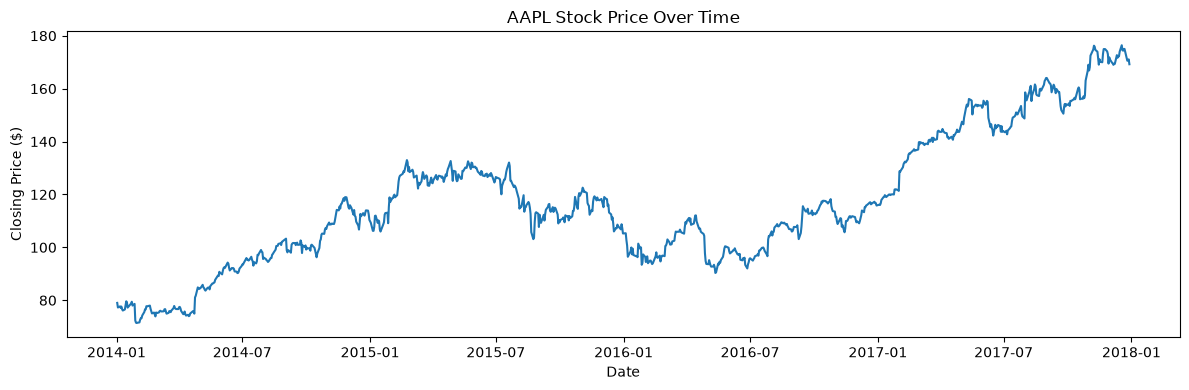

In [34]:
plt.figure(figsize=(12,4))
plt.plot(close_price.index, close_price.values)
plt.title(f"{symbol} Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.tight_layout()
plt.show()


With the clean series ready, I began the analysis. I first plotted the raw closing price over time to see the overall behavior of the stock. This revealed the general path the price took across the period.

### decompose means to break down a single, complex timeline of data into its separate, simpler hidden patterns.

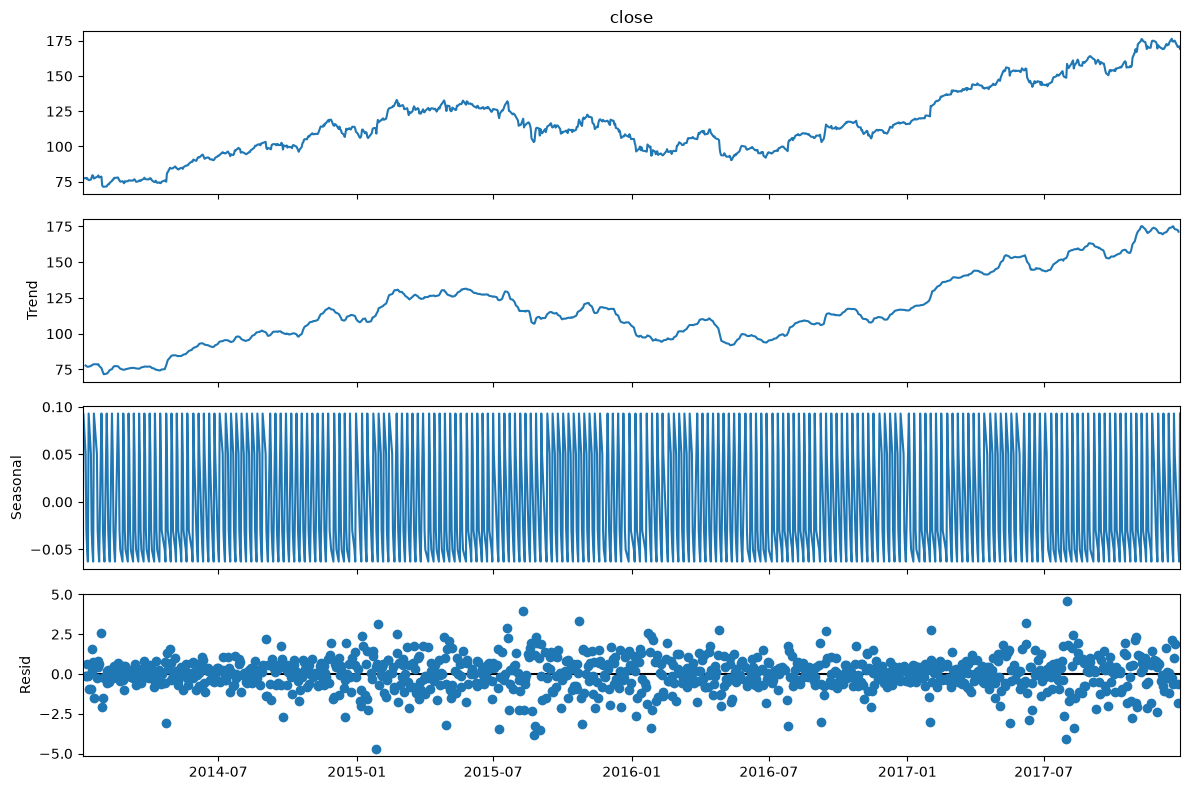

In [35]:
# Decompose
dec = seasonal_decompose(close_price, model='additive', period=5)
fig = dec.plot()
fig.set_size_inches(12,8)
plt.tight_layout()
plt.show()

I decomposed the series into three components: trend, seasonality, and residuals. The trend shows the long-term direction of the price; the seasonal component captures any fixed repeating pattern (such as a weekly cycle); and the residuals represent the random noise left after the other two are removed. For daily stock data, the seasonal component is typically very small, which itself is a meaningful finding — stock prices are driven more by trend and randomness than by regular cycles.

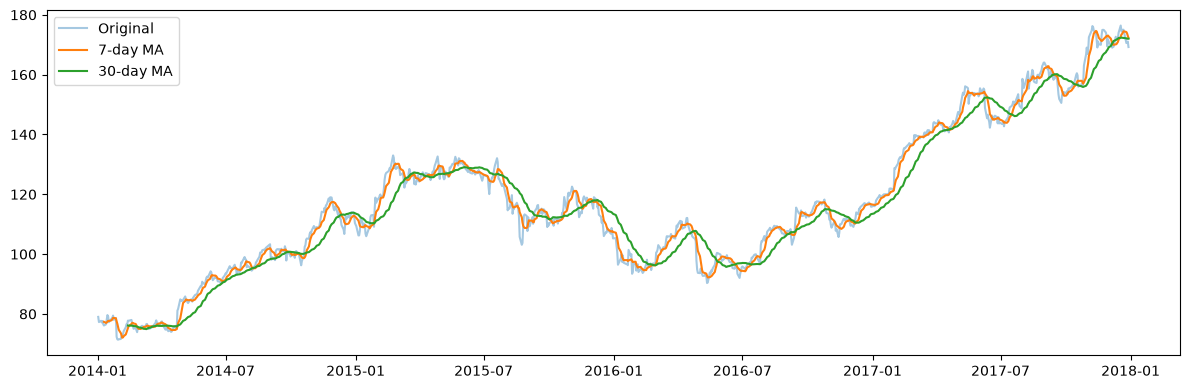

In [36]:
#  Moving averages
plt.figure(figsize=(12,4))
plt.plot(close_price.index, close_price.values, label='Original', alpha=0.4)
for w in [7,30]:
    plt.plot(close_price.rolling(w).mean().index,
             close_price.rolling(w).mean().values, label=f'{w}-day MA')
plt.legend(); plt.tight_layout(); plt.show()

Finally, I applied moving-average smoothing using 7-day and 30-day windows. Because daily prices are noisy, a moving average replaces each day with the average of the surrounding days, making the underlying direction clearer. The shorter window follows the price closely, while the longer window reveals the broader trend and helps identify whether momentum is rising or falling.

### Include overall
1. Loaded the full CSV (489 stocks) into df2.
2. Converted date to datetime and sorted chronologically.
3. Dropped the 1 row missing close/volume (no gaps).
4. Filtered to AAPL only → got (311, 10): 311 trading days, 10 columns.
5. Set date as index, so each row is one day's prices.

# Task 3: Clustering Analysis (KMeans)


Description: Implement K-Means clustering to group
similar data points together based on feature
similarities.
Standardize the dataset (e.g., using StandardScaler).
Apply K-Means clustering and determine the optimal
number of clusters using the elbow method.
Visualize clusters using 2D scatter plots.
### Objettive

Tools: Python, scikit-learn, matplotlib, seaborn.

In [37]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [38]:
df = pd.read_csv("cleaned_iris_dataset.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [39]:
# Select numeric features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
true_species = df['species']


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

The "elbow" in K-Means clustering refers to a graphical technique used to find the best number of clusters (k)

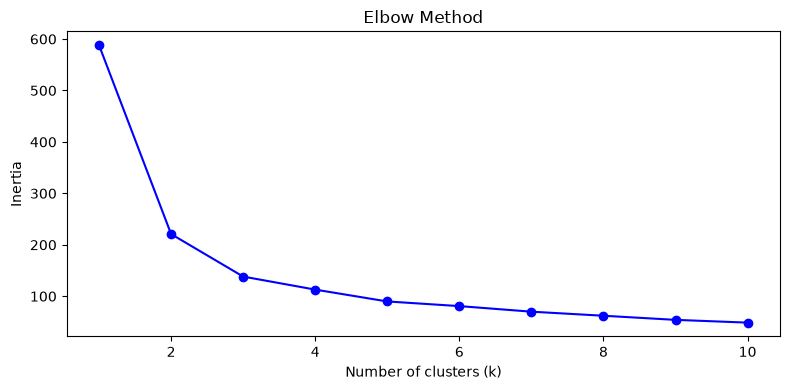

In [41]:
# Elbow method
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()


In [42]:
# Final model
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(df['cluster'].value_counts())

cluster
0    52
1    48
2    47
Name: count, dtype: int64


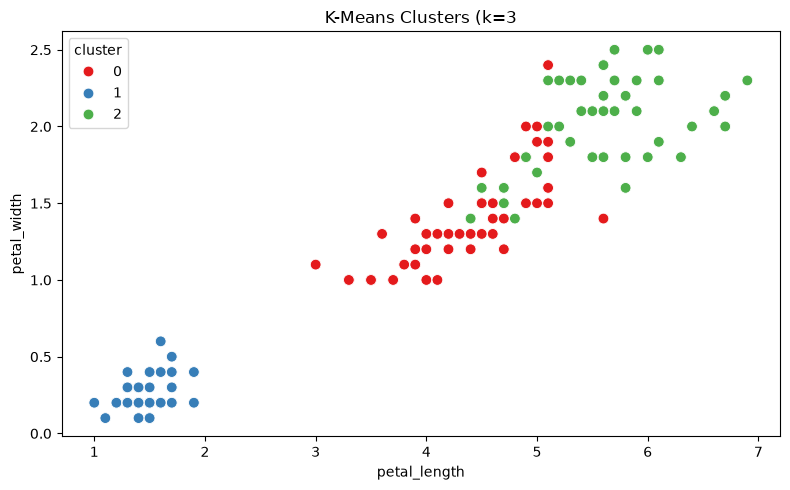

In [43]:
# scatter plot 2D array
plt.figure(figsize = (8,5))
sns.scatterplot(data=df, x = 'petal_length', y = 'petal_width', hue = 'cluster', palette = 'Set1', s = 60)
plt.title(f'K-Means Clusters (k={best_k}')
plt.tight_layout()
plt.show()

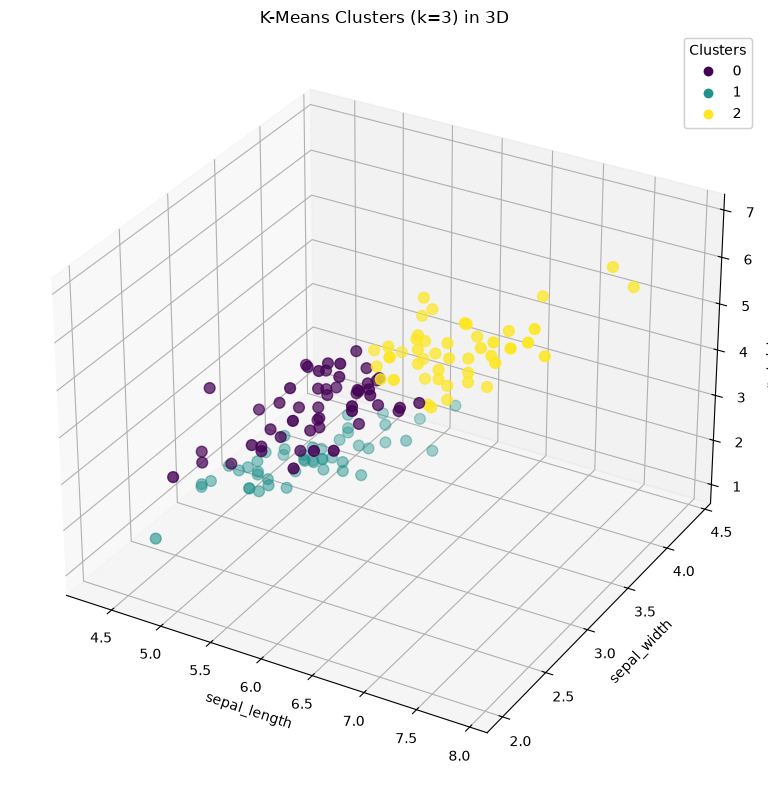

In [44]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['sepal_length'], df['sepal_width'], df['petal_length'],
                     c=df['cluster'], cmap='viridis', s=60)

ax.set_xlabel('sepal_length')
ax.set_ylabel('sepal_width')
ax.set_zlabel('petal_length')
ax.set_title(f'K-Means Clusters (k={best_k}) in 3D')

# Create a legend for the clusters
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [45]:
# Compare to true species
print(pd.crosstab(df['cluster'], true_species))

species  setosa  versicolor  virginica
cluster                               
0             0          39         13
1            48           0          0
2             0          11         36


#### Interpretation of Clustering Results

The `pd.crosstab` output helps us understand how well the K-Means algorithm grouped the data points compared to their actual species labels. Each row represents a cluster identified by K-Means, and each column represents a true species.

From the table:

*   **Cluster 1** (row index `1`) perfectly captures **all 48 'setosa' species** instances. This indicates excellent separation for this species.
*   **Cluster 0** (row index `0`) primarily contains **'versicolor' species (39 instances)**, with a smaller number of 'virginica' (13 instances). This cluster is predominantly 'versicolor'.
*   **Cluster 2** (row index `2`) largely consists of **'virginica' species (36 instances)**, along with some 'versicolor' (11 instances). This cluster is mainly 'virginica'.

Overall, the K-Means clustering with k=3 shows a strong alignment with the actual species, especially for 'setosa'. There's some overlap between 'versicolor' and 'virginica' in clusters 0 and 2, which is common in clustering tasks where the boundaries between classes might not be perfectly distinct.